# Task 3: Feature Engineering

This notebook uses reusable functions from the `src` folder to create customer-level behavioral features, perform RFM analysis, apply K-Means clustering, and generate a proxy target variable for credit risk modeling.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to Python path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.data_processing import load_data, summarize_data_quality, count_duplicates
from src.feature_engineering import (
    convert_transaction_time,
    create_customer_features,
    create_rfm_features,
    assign_risk_clusters,
    identify_high_risk_cluster,
    create_proxy_target,
    merge_proxy_target,
    encode_categorical_features,
    save_processed_data
)

In [2]:
data_path = "../data/raw/data.csv"

df = load_data(data_path)

df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [3]:
df.shape

(95662, 16)

In [4]:
summarize_data_quality(df)

,missing_values,missing_percentage
TransactionId,0,0.0
BatchId,0,0.0
AccountId,0,0.0
SubscriptionId,0,0.0
CustomerId,0,0.0
CurrencyCode,0,0.0
CountryCode,0,0.0
ProviderId,0,0.0
ProductId,0,0.0
ProductCategory,0,0.0


In [5]:
count_duplicates(df)

0

In [6]:
df = convert_transaction_time(df)

df["TransactionStartTime"].head()

0   2018-11-15 02:18:49+00:00
1   2018-11-15 02:19:08+00:00
2   2018-11-15 02:44:21+00:00
3   2018-11-15 03:32:55+00:00
4   2018-11-15 03:34:21+00:00
Name: TransactionStartTime, dtype: datetime64[us, UTC]

In [7]:
customer_df = create_customer_features(df)

customer_df.head()

,CustomerId,transaction_count,total_amount,avg_amount,std_amount,total_value,avg_value,first_transaction,last_transaction
0,CustomerId_1,1,-10000.0,-10000.000000,0.000000,10000,10000.000000,2018-11-21 16:49:14+00:00,2018-11-21 16:49:14+00:00
1,CustomerId_10,1,-10000.0,-10000.000000,0.000000,10000,10000.000000,2018-11-21 16:49:09+00:00,2018-11-21 16:49:09+00:00
2,CustomerId_1001,5,20000.0,4000.000000,6558.963333,30400,6080.000000,2018-11-16 07:53:19+00:00,2018-11-16 08:20:39+00:00
3,CustomerId_1002,11,4225.0,384.090909,560.498966,4775,434.090909,2018-11-15 18:50:09+00:00,2019-01-18 10:05:00+00:00
4,CustomerId_1003,6,20000.0,3333.333333,6030.478146,32000,5333.333333,2019-02-01 14:58:07+00:00,2019-02-01 15:04:51+00:00


In [8]:
customer_df = create_rfm_features(customer_df)

customer_df[["CustomerId", "recency_days", "frequency", "monetary"]].head()

,CustomerId,recency_days,frequency,monetary
0,CustomerId_1,83,1,-10000.0
1,CustomerId_10,83,1,-10000.0
2,CustomerId_1001,89,5,20000.0
3,CustomerId_1002,25,11,4225.0
4,CustomerId_1003,11,6,20000.0


## RFM Feature Engineering

RFM features summarize customer transaction behavior:

- Recency measures how recently a customer made a transaction.
- Frequency measures how often a customer transacts.
- Monetary value measures the total transaction value contributed by the customer.

Some customers contain negative monetary values, which may represent withdrawals, reversals, refunds, or cash-out transactions commonly observed in financial systems.

These features are useful because the dataset does not contain a direct loan default label. Customer transaction behavior is therefore used to create a proxy risk signal.

In [9]:
customer_df = assign_risk_clusters(customer_df)

customer_df[["CustomerId", "recency_days", "frequency", "monetary", "cluster"]].head()

,CustomerId,recency_days,frequency,monetary,cluster
0,CustomerId_1,83,1,-10000.0,0
1,CustomerId_10,83,1,-10000.0,0
2,CustomerId_1001,89,5,20000.0,0
3,CustomerId_1002,25,11,4225.0,1
4,CustomerId_1003,11,6,20000.0,1


In [10]:
cluster_summary = customer_df.groupby("cluster")[[
    "recency_days",
    "frequency",
    "monetary"
]].mean()

cluster_summary

,recency_days,frequency,monetary
cluster,,,
0,60.877279,7.720196,8.172068e+04
1,11.726566,34.800000,2.725741e+05
2,28.000000,4091.000000,-1.049000e+08


In [11]:
high_risk_cluster = identify_high_risk_cluster(customer_df)

high_risk_cluster

0

### Cluster Interpretation

Cluster-level analysis was used to understand customer behavioral segments.

Cluster 0 showed:
- the highest recency values
- lower transaction frequency
- weaker engagement patterns

This cluster was therefore selected as the proxy high-risk segment for downstream credit risk modeling.

In [12]:
customer_df = create_proxy_target(customer_df, high_risk_cluster)

customer_df[["CustomerId", "cluster", "is_high_risk"]].head()

,CustomerId,cluster,is_high_risk
0,CustomerId_1,0,1
1,CustomerId_10,0,1
2,CustomerId_1001,0,1
3,CustomerId_1002,1,0
4,CustomerId_1003,1,0


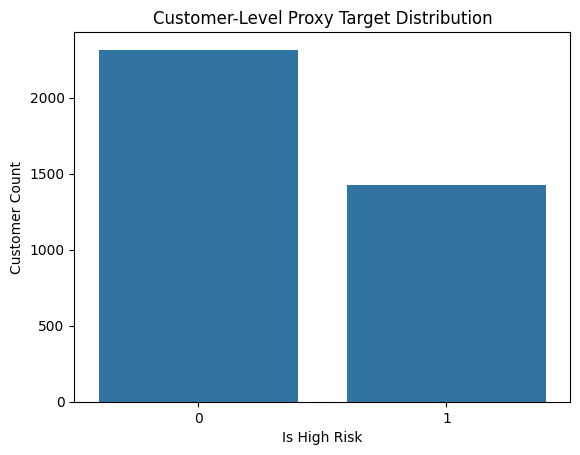

In [13]:
sns.countplot(data=customer_df, x="is_high_risk")

plt.title("Customer-Level Proxy Target Distribution")
plt.xlabel("Is High Risk")
plt.ylabel("Customer Count")
plt.show()

## Proxy Target Variable

K-Means clustering was applied to RFM features to segment customers into behavioral risk groups based on transaction activity patterns.

Cluster analysis showed that Cluster 0 had:
- higher recency values, indicating longer inactivity periods
- lower transaction frequency
- weaker overall customer engagement behavior

Because the dataset does not contain an actual loan default label, this behavioral segment was selected as the high-risk group and converted into a binary proxy target variable called `is_high_risk`.

Customers belonging to the selected cluster were assigned:
- `1` → high-risk customer
- `0` → lower-risk customer